In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('dataset_esercitazione.csv')
print(data.shape)
target = data['dzgroup']
data = data.drop(columns=['dzgroup', 'dzclass'])
X_train, X_temp, y_train, y_temp = train_test_split(data, target, test_size=0.2, random_state=42, stratify=target)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

nan_percentage = X_train.isna().sum() / X_train.shape[0] * 100
print(f"Percentuale di nan nei dati: {nan_percentage.sort_values(ascending=False)}%")

(9105, 43)
Percentuale di nan nei dati: adlp        61.957716
urine       53.542010
glucose     49.766612
bun         48.091708
totmcst     38.248215
alb         37.040088
income      32.880286
adls        31.438770
bili        29.022515
pafi        25.604064
ph          25.082372
prg2m       18.190555
prg6m       17.984624
edu         17.915980
totcst       9.678748
wblc         2.388797
charges      1.935750
avtisst      0.974739
crea         0.727622
race         0.466776
dnr          0.329489
dnrday       0.329489
sps          0.013729
resp         0.013729
scoma        0.013729
sod          0.013729
hrt          0.013729
meanbp       0.013729
temp         0.013729
surv2m       0.013729
surv6m       0.013729
aps          0.013729
age          0.000000
num.co       0.000000
sex          0.000000
hday         0.000000
diabetes     0.000000
ca           0.000000
dementia     0.000000
adlsc        0.000000
death        0.000000
dtype: float64%


In [7]:
threshold = 15 

cols_to_drop = nan_percentage[nan_percentage > threshold].index
print(cols_to_drop)

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)

print(f"Nuovo numero di colonne: {X_train.shape[1]}")

Index(['edu', 'income', 'totmcst', 'prg2m', 'prg6m', 'pafi', 'alb', 'bili',
       'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls'],
      dtype='object')
Nuovo numero di colonne: 27


In [8]:
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

for df in [X_val, X_test]:
    df[num_cols] = num_imputer.transform(df[num_cols])
    df[cat_cols] = cat_imputer.transform(df[cat_cols])
    
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_val[cat_cols] = encoder.transform(X_val[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)


from sklearn.preprocessing import StandardScaler
# Codificando con ordinal Encoding le feature categoriche ora hanno un ordinamento numerico. Devo scalarle per evitare che il modello dia più importanza a quelle con valori più alti.
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [9]:
print(type(y_train))

<class 'numpy.ndarray'>


In [10]:
corr = X_train.corrwith(pd.Series(y_train, index=X_train.index)).abs()
print(corr.sort_values(ascending=False))

surv6m      0.377034
ca          0.348049
death       0.267228
surv2m      0.267180
dnrday      0.223030
totcst      0.190499
avtisst     0.189145
charges     0.188757
aps         0.158923
dnr         0.136438
diabetes    0.130433
scoma       0.086702
sps         0.084742
crea        0.074453
num.co      0.072133
dementia    0.062857
hday        0.058097
wblc        0.039014
meanbp      0.034887
race        0.034237
age         0.032484
temp        0.029883
sod         0.028784
resp        0.018809
adlsc       0.013380
hrt         0.010327
sex         0.000688
dtype: float64


In [11]:
corr = X_train.corr()

columns = corr.columns

for i in range(len(columns)):
    for j in range(i+1, len(columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"Colonne {columns[i]} e {columns[j]} sono altamente correlate con coefficiente di correlazione: {corr.iloc[i, j]}")

Colonne charges e totcst sono altamente correlate con coefficiente di correlazione: 0.7392528080925291
Colonne sps e aps sono altamente correlate con coefficiente di correlazione: 0.7971296660128568
Colonne sps e surv2m sono altamente correlate con coefficiente di correlazione: -0.7590649548352068
Colonne surv2m e surv6m sono altamente correlate con coefficiente di correlazione: 0.9604158328199266


In [12]:
highly_correlated = [['charges', 'totcst'], ['sps', 'aps'], ['surv2m', 'surv6m']]

for cols in highly_correlated:
    for df in [X_train, X_val, X_test]:
        df['_'.join(cols)] = df[cols].mean(axis=1)
        df.drop(columns=cols, inplace=True)
        
print(X_train.columns.tolist())

['age', 'sex', 'num.co', 'scoma', 'avtisst', 'race', 'hday', 'diabetes', 'dementia', 'ca', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'crea', 'sod', 'adlsc', 'death', 'charges_totcst', 'sps_aps', 'surv2m_surv6m']


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "criterion": ['gini', 'log_loss'],
    "min_samples_split": [2, 5, 10],
    'max_features': ['sqrt', 5]
}

rf = RandomForestClassifier(random_state=42)
gs = GridSearchCV(rf, params, scoring='accuracy', cv=5, verbose=1)
gs.fit(X_train, y_train)

print("Migliori parametri:", gs.best_params_)
print("Migliore score:", gs.best_score_)

print("Miglior score sulla validation set:", gs.score(X_val, y_val))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori parametri: {'criterion': 'log_loss', 'max_features': 5, 'min_samples_split': 5}
Migliore score: 0.7123841326826914
Miglior score sulla validation set: 0.7406593406593407


In [25]:
import torch
from torch.utils.data import Dataset
import torchnn as utils
import numpy as np
#trasformare dataframe in tensori

class MyDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X, dtype=torch.float32)
        
        self.X = self.X.unsqueeze(1)
        
        self.y = torch.tensor(y,dtype=torch.long)
        
    def __len__(self):
        # Dice a PyTorch quanti record ci sono nel dataset
        return len(self.X)
    
    def __getitem__(self,idx):
        
        return self.X[idx], self.y[idx]
    
train_loader, val_loader, test_loader = utils.make_dataloaders(
    MyDataset(np.array(X_train),np.array(y_train)),
    MyDataset(np.array(X_val),np.array(y_val)),
    MyDataset(np.array(X_test),np.array(y_test)),
    batch=64
)

/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape e tipo dei campioni: torch.Size([64, 1, 24]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [ ]:
import torch.nn as nn

class Net(nn.Module):
    
    def __init__(self,num_features, num_classes):
        super().__init__()
        
        self.layers = nn.Sequential(
            # Entra 1 canale (grazie all'unsqueeze), escono 32 mappe geometriche.
            # Kernel_size=3 significa che analizza le colonne a gruppi di 3 vicine.
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Seconda convoluzione: aumenta la complessità a 64 canali
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Il Pooling fa la media a coppie e DIMEZZA la lunghezza delle colonne
            nn.AvgPool1d(kernel_size=2),
            
            # Trasforma le matrici rimaste in un unico vettore piatto continuo
            nn.Flatten(),
            
            # STRATO DENSO (Linear): L'input deve essere pari a: Canali_Uscita (64) * Lunghezza_Colonne_Dimezzata
            nn.Linear(64 * (num_features // 2), 256),
            nn.ReLU(),
            
            # STRATO FINALE: Tanti neuroni quanti sono le classi da indovinare
            nn.Linear(256, num_classes),
            
            # LogSoftmax distribuisce l'output sotto forma di logaritmi di probabilità
            nn.LogSoftmax(dim=1)
        )
        
    def forward(self,X):
        
        return self.layers(X)
    
# Inizializziamo il modello passando il numero di colonne e il numero di classi del target
model = Net(num_features=X_train.shape[1], num_classes=len(np.unique(y_train)))

In [29]:
# 1. Loss function coerente con il LogSoftmax finale



import copy


criterion = nn.NLLLoss() 

# 2. Ottimizzatore Adam (regola i pesi della rete con un tasso di apprendimento di 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Classe del tuo collega per salvare il modello migliore durante la validazione
class SaveBestModel:
    def __init__(self):
        self.best_loss = float('inf')
        self.best_model_state = None
        
    def __call__(self, current_loss, model):
        if current_loss < self.best_loss:
            self.best_loss = current_loss
            # Salva in memoria una copia congelata dei pesi migliori trovati
            self.best_model_state = copy.deepcopy(model.state_dict())
            
    def load_best(self, model):
        # Ripristina i pesi migliori nel modello prima del test finale
        model.load_state_dict(self.best_model_state)

saver = SaveBestModel()

In [30]:
epochs = 20

for epoch in range(epochs):
    # --- FASE 1: ADDESTRAMENTO ---
    model.train() # Mette la rete in modalità addestramento
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()       # 1. Azzera i residui del giro precedente
        outputs = model(X_batch)     # 2. Fai la predizione (Forward)
        loss = criterion(outputs, y_batch) # 3. Calcola l'errore
        loss.backward()             # 4. Calcola la colpa dei neuroni (Backward)
        optimizer.step()            # 5. Aggiorna i pesi dei neuroni
        train_loss += loss.item()
        
    # --- FASE 2: VALIDAZIONE ---
    model.eval() # Mette la rete in modalità esame (disattiva modifiche)
    val_loss = 0.0
    
    with torch.no_grad(): # Disattiva il calcolo dei gradienti (risparmia memoria al PC dell'esame)
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            
    # Calcoliamo l'errore medio di questa epoca
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoca {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Controlliamo se questa epoca ha prodotto il modello migliore
    saver(avg_val_loss, model)

# Alla fine di tutte le epoche, carichiamo lo stato migliore della rete
saver.load_best(model)
print("Pesi ottimali caricati con successo!")

/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoca 1/20 -> Train Loss: 0.8544 | Val Loss: 0.7777
Epoca 2/20 -> Train Loss: 0.7671 | Val Loss: 0.7664
Epoca 3/20 -> Train Loss: 0.7211 | Val Loss: 0.6897
Epoca 4/20 -> Train Loss: 0.6920 | Val Loss: 0.6657
Epoca 5/20 -> Train Loss: 0.6631 | Val Loss: 0.6644
Epoca 6/20 -> Train Loss: 0.6464 | Val Loss: 0.6233
Epoca 7/20 -> Train Loss: 0.6200 | Val Loss: 0.6328
Epoca 8/20 -> Train Loss: 0.6008 | Val Loss: 0.6665
Epoca 9/20 -> Train Loss: 0.5889 | Val Loss: 0.6597
Epoca 10/20 -> Train Loss: 0.5741 | Val Loss: 0.6086
Epoca 11/20 -> Train Loss: 0.5535 | Val Loss: 0.6207
Epoca 12/20 -> Train Loss: 0.5415 | Val Loss: 0.6198
Epoca 13/20 -> Train Loss: 0.5296 | Val Loss: 0.6631
Epoca 14/20 -> Train Loss: 0.5105 | Val Loss: 0.6452
Epoca 15/20 -> Train Loss: 0.5052 | Val Loss: 0.6227
Epoca 16/20 -> Train Loss: 0.4887 | Val Loss: 0.6074
Epoca 17/20 -> Train Loss: 0.4797 | Val Loss: 0.5983
Epoca 18/20 -> Train Loss: 0.4575 | Val Loss: 0.6105
Epoca 19/20 -> Train Loss: 0.4506 | Val Loss: 0.5992
Ep

In [31]:
from sklearn.metrics import roc_auc_score


model.eval()

y_true = []
y_pred_proba = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        
        # TRUCCO CRITICO PER L'AUC: Poiché l'uscita è un LogSoftmax (logaritmo),
        # usiamo torch.exp() per riportare i valori in probabilità reali (da 0 a 1)
        probs = torch.exp(outputs)
        
        # Salviamo i risultati convertendoli in normali array NumPy
        y_true.extend(y_batch.cpu().numpy())
        y_pred_proba.extend(probs.cpu().numpy())

# Convertiamo in array definitivi
y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)

# Calcoliamo la metrica richiesta dalla traccia: AUC-ROC Multiclasse One-Vs-Rest pesata
auc_score = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')
print(f"\n>>>> RETE NEURALE - AUC-ROC FINALE SUL TEST SET: {auc_score:.4f} <<<<")


>>>> RETE NEURALE - AUC-ROC FINALE SUL TEST SET: 0.9516 <<<<


/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text(0.5, 1.0, 'NN')

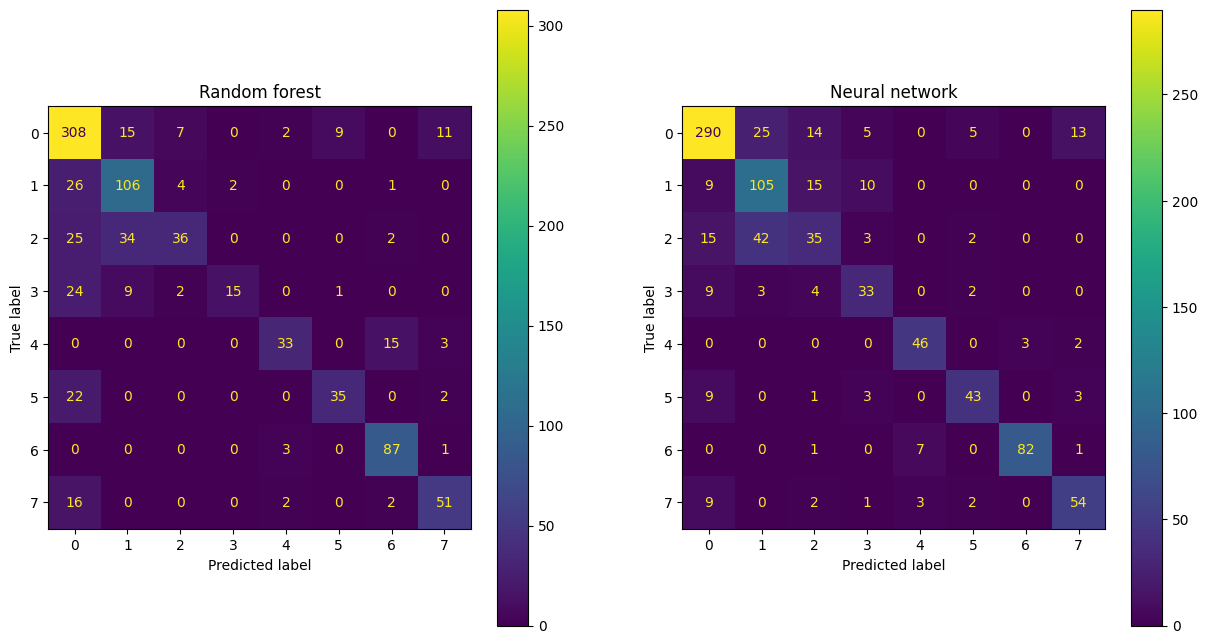

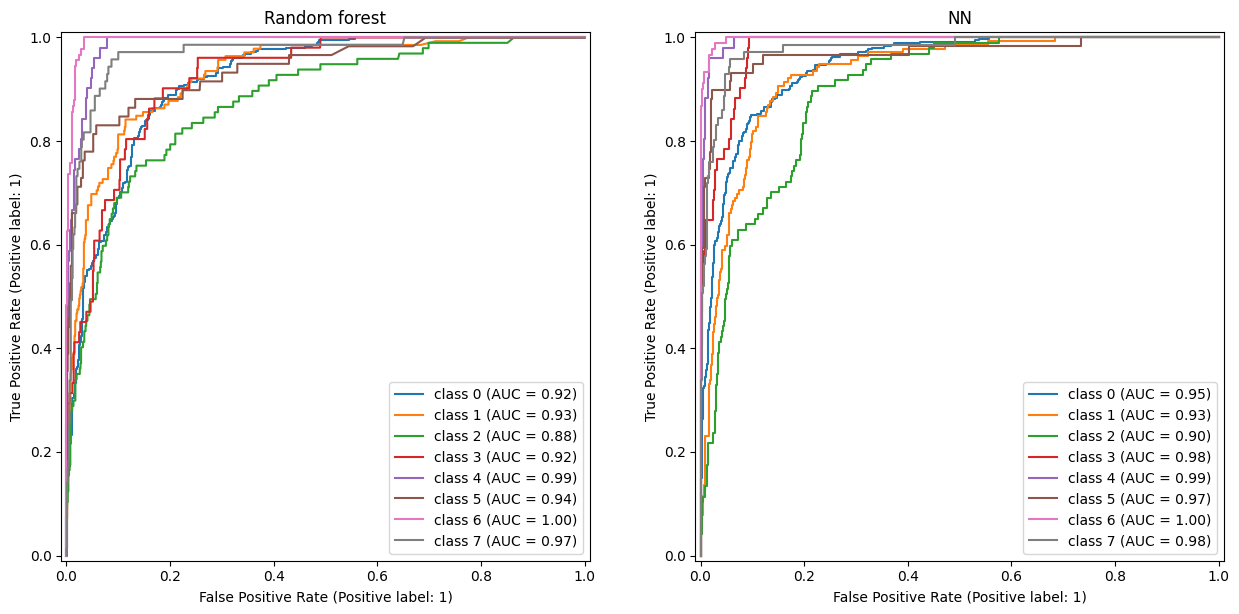

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import label_binarize

model.load_state_dict(save_best_model.best_model_state)

y_pred_rf = gs.best_estimator_.predict(X_test)
y_pred_proba_rf = gs.best_estimator_.predict_proba(X_test)
_, _, _, (y_true_nn, y_pred_nn, y_pred_proba_nn) = eval_loop(model, test_dataloader, device, criterion)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[0])
ax[0].set_title('Random forest')

ConfusionMatrixDisplay.from_predictions(y_true_nn, y_pred_nn, ax=ax[1])
ax[1].set_title('Neural network')
n_classes = len(label_encoder.classes_)
y_test_rf_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_true_nn_bin = label_binarize(y_true_nn, classes=np.arange(n_classes))

fig, ax = plt.subplots(1, 2, figsize=(15,8))
for cls in range(n_classes):
    RocCurveDisplay.from_predictions(y_test_rf_bin[:,cls], y_pred_proba_rf[:,cls], ax=ax[0], name=f"class {cls}")
    RocCurveDisplay.from_predictions(y_true_nn_bin[:,cls], y_pred_proba_nn[:,cls], ax=ax[1], name=f"class {cls}")

ax[0].set_title('Random forest')
ax[1].set_title('NN')



In [ ]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='macro')
auc_nn = roc_auc_score(y_true_nn, y_pred_proba_nn, multi_class='ovr', average='macro')

print(f"AUC Random Forest: {auc_rf:.4f}")
print(f"AUC Neural Network: {auc_nn:.4f}")

AUC Random Forest: 0.9423
AUC Neural Network: 0.9618
